In [3]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import statsmodels

Here, We have loaded the dataset. 
dataset link :https://www.kaggle.com/zaurbegiev/my-dataset?select=credit_train.csv

In [5]:
credit_data = pd.read_csv('Datasets/credit_train.csv')

credit_data.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6,1,228190,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35,0,229976,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18,1,297996,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9,0,256329,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15,0,253460,427174.0,0.0,0.0


In [6]:
credit_data.shape

(100000, 19)

In [7]:
credit_data = credit_data.drop_duplicates()

credit_data = credit_data.dropna()

credit_data.shape

(31254, 19)

Viewing the Descriptive statistics of the Dataset


In [8]:
credit_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,31254.0,1.599975e+07,3.630042e+07,21450.0,194573.5000,327030.00,559020.00,1.000000e+08
Credit Score,31254.0,1.114460e+03,1.544753e+03,585.0,705.0000,725.00,740.00,7.510000e+03
Annual Income,31254.0,1.460592e+06,9.378285e+05,111245.0,930002.5000,1258142.00,1740309.75,3.083900e+07
Monthly Debt,31254.0,1.922066e+04,1.209854e+04,0.0,11086.9275,17061.24,24703.80,2.290579e+05
Years of Credit History,31254.0,1.910217e+01,6.670789e+00,3.8,14.5000,17.80,22.50,7.050000e+01
Months since last delinquent,31254.0,3.494215e+01,2.192386e+01,0.0,16.0000,32.00,51.00,1.760000e+02
Number of Open Accounts,31254.0,1.150883e+01,4.991969e+00,1.0,8.0000,11.00,14.00,4.800000e+01
Number of Credit Problems,31254.0,1.837205e-01,5.268546e-01,0.0,0.0000,0.00,0.00,1.500000e+01
Current Credit Balance,31254.0,2.641227e+05,3.197944e+05,0.0,101673.7500,187359.00,328448.25,7.350321e+06
Maximum Open Credit,31254.0,6.800816e+05,6.054028e+06,0.0,249788.0000,425293.00,710611.00,7.982554e+08


Regplot is plot used to depict linear relationships between variables through Regression.Scatterplot is drawn for the two variables and a regression model(y~x) is fitted with a regression line plotted with a 95% confidence interval.
The width of confidence interval is increasing from left to right as the no. of  datapoints are reducing sharply.
Here in the below plot, Moderate Positive correlation is observed as the data points are more or less tightly fiiting the Regression line with few outliers. So As 'Annual Income' for customers increases,the Monthly Debt also increases. .The resulting regression line is drawn with  a 95% confidence interval for that regression.Also note that Regplot function is a axes level function.

Lmplot is also used to visualize a linear relationship as determined through regression. But Lmplot is a figure level function built on top of Facetgrid. Regplot possess a subset of features of Lmplot.


<AxesSubplot:xlabel='Monthly Debt', ylabel='Months since last delinquent'>

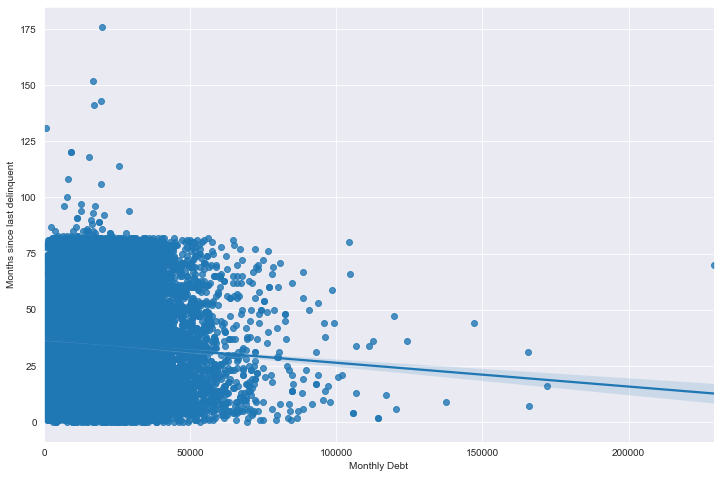

In [15]:
sns.set_style('darkgrid')

f, ax = plt.subplots(figsize = (12, 8))

sns.regplot(x = 'Monthly Debt', y = 'Months since last delinquent', data = credit_data)

Regression lines can be disabled by setting 'fit_reg' to False

<AxesSubplot:xlabel='Annual Income', ylabel='Monthly Debt'>

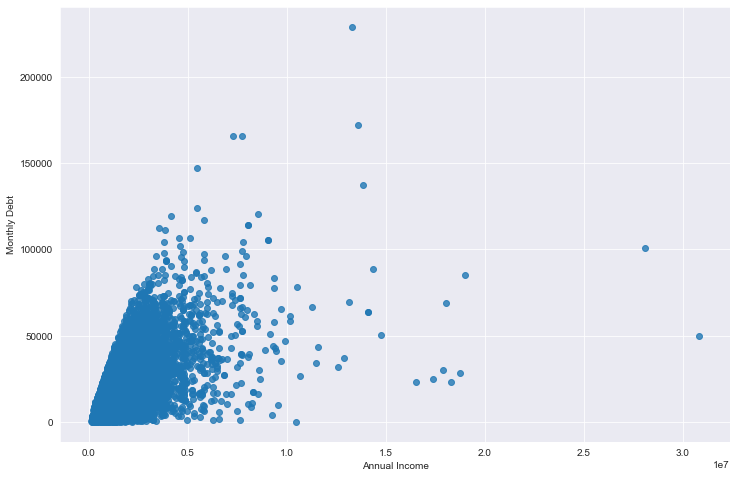

In [17]:
f, ax = plt.subplots(figsize = (12, 8))

sns.regplot(x = 'Annual Income', y = 'Monthly Debt', 
            fit_reg = False, data = credit_data)

We can also hide all the data points in the scatter plot to show only the regression line by setting scatter=False

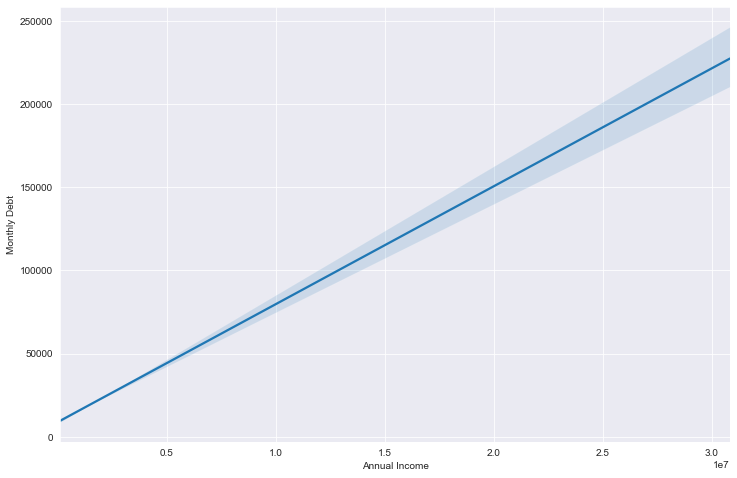

In [18]:
f, ax = plt.subplots(figsize = (12, 8))

sns.regplot(x = 'Annual Income', y = 'Monthly Debt', 
            scatter = False, data = credit_data)

We can also pass pandas series objects to regplot() but lmplot() has data as the required argument and accepts only strings as X and Y variables.
Here, We have drawn a Scatter plot fitted with Regression line between 'Monthly Debt' and 'Current Credit Balance'.
Positive correlation is observed between them.

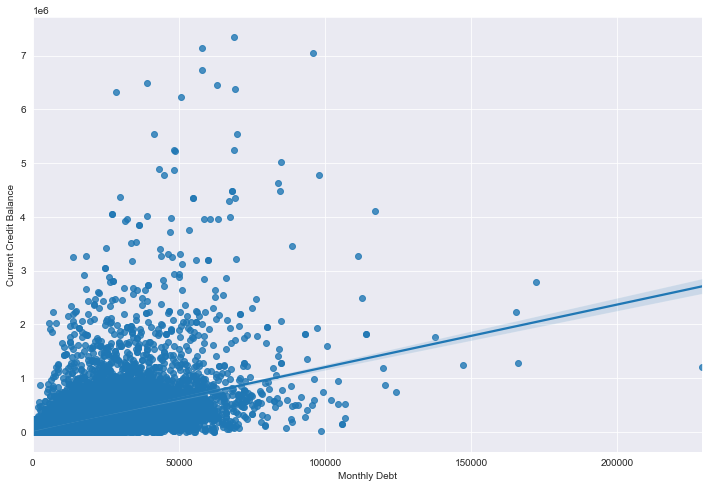

In [19]:
f, ax = plt.subplots(figsize = (12, 8))

sns.regplot(x = credit_data['Monthly Debt'], y = credit_data['Current Credit Balance'])

The plot generated by lmplot() is similar to regplot().Only the figure shapes are different. Note that Lmplot function is a Figure level function and is built on top of a FacetGrid object. 

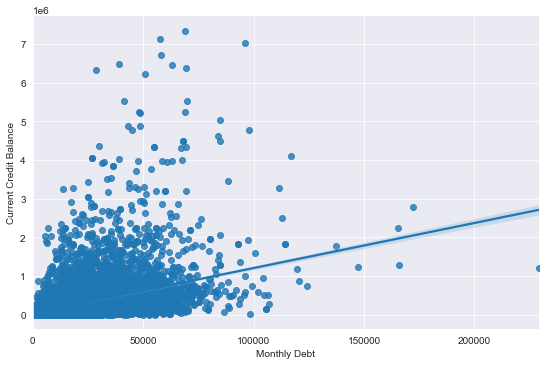

In [20]:
sns.lmplot(x = 'Monthly Debt', y = 'Current Credit Balance', 
           data = credit_data, aspect = 1.5)

We have removed the display of confidence interval by putting 'ci' value to None.

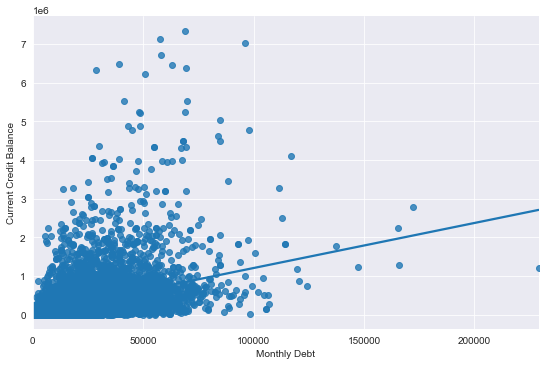

In [21]:
sns.lmplot(x = 'Monthly Debt', y = 'Current Credit Balance', 
           data = credit_data, aspect = 1.5, ci = None)

Same plot can be drawn with Relplot function. Only the plot markers are different.

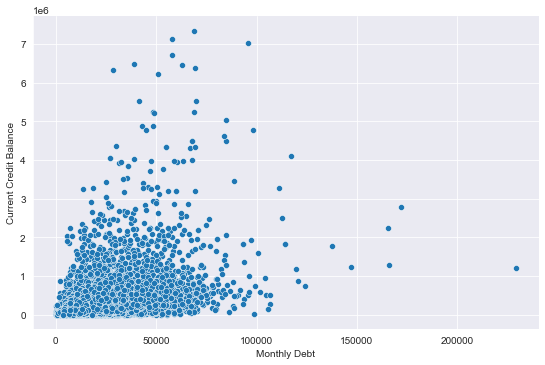

In [22]:
sns.relplot(x = 'Monthly Debt', y = 'Current Credit Balance', 
            data = credit_data , aspect = 1.5)

Here, We have drawn a scatterplot of  'Bankruptcies' and  'Number of Credit Problems'. Note that both the variables are taking discrete values.Strong Positive correlation exists between them. It is clearly observed that As the Number of Credit problems for customer increases, there is a increase in Number of Bankruptcies.
Here also,the width of 'ci' is increasing from left to right as the no .of data points are reducing from left to right.


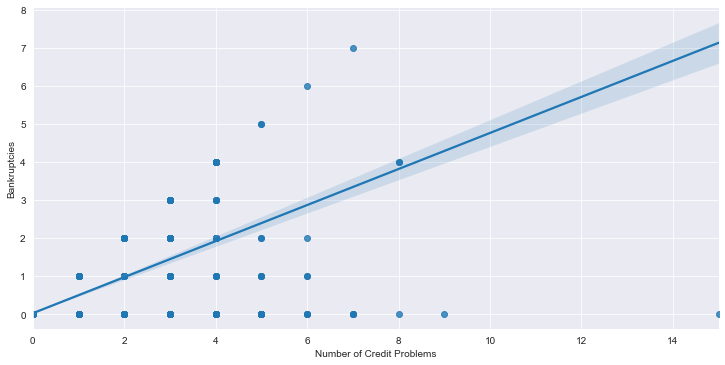

In [25]:
sns.lmplot(x = 'Number of Credit Problems', y = 'Bankruptcies', 
           data = credit_data, aspect = 2)

Here one of the variable 'Number of Open Accounts' is discrete,it is also observed that as 'Monthly debt' is somewhat increasing with 'Number of Open Accounts'.Weak Positive correlation observed between the two variables.

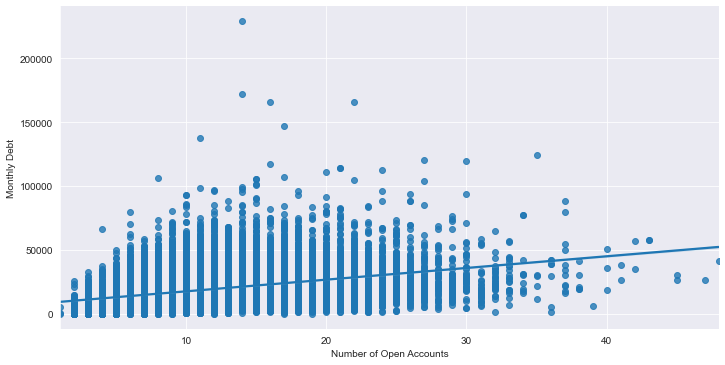

In [26]:
sns.lmplot(x = 'Number of Open Accounts', y = 'Monthly Debt', 
           data = credit_data, aspect = 2)

We can add some random noise (“jitter”) to the discrete values to reduce overlapping of data points.

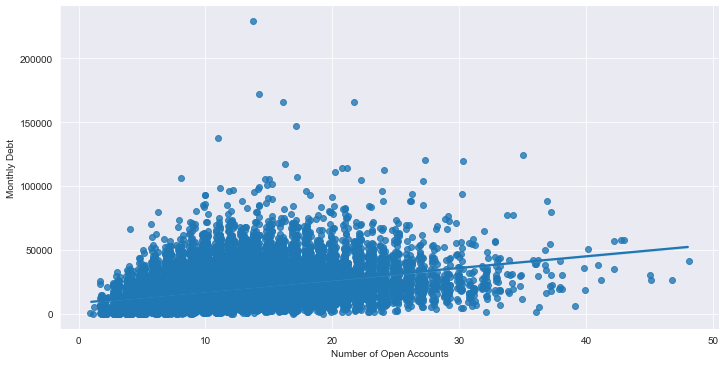

In [27]:
sns.lmplot(x = 'Number of Open Accounts' , y = 'Monthly Debt',
           data = credit_data, x_jitter = 0.3, aspect = 2)

Using x_estimator argument we have plotted an estimate of mean values along with a confidence interval for each discrete bin. Here it is quite evident that data points have become smoother due to aggregation of points through mean.

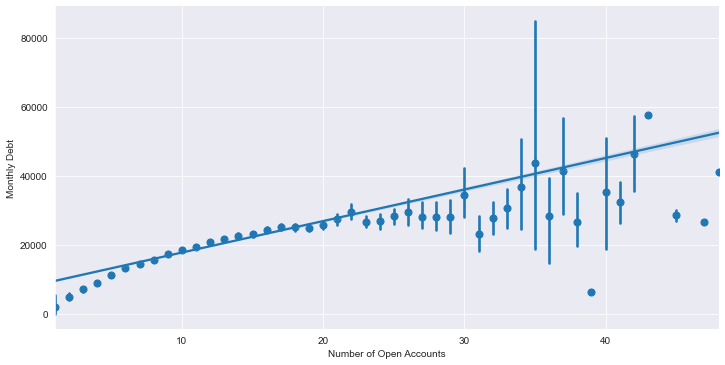

In [28]:
sns.lmplot(x = 'Number of Open Accounts' , y = 'Monthly Debt', 
           data = credit_data , aspect = 2, x_estimator = np.mean)

Here ,We have drawn a scatterplot of  'Monthly Debt' and 'Annual Income' with no additional variables included in the plot.

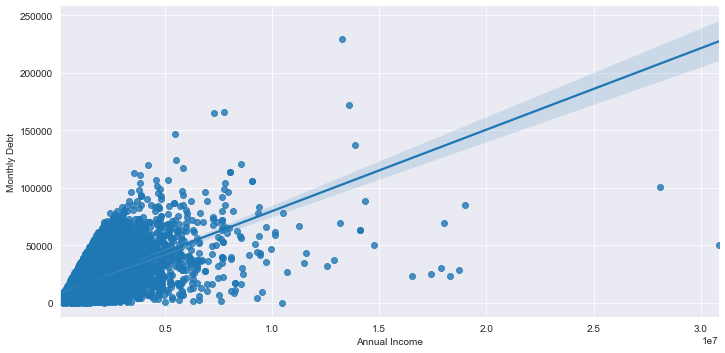

In [29]:
sns.lmplot(x = 'Annual Income' , y = 'Monthly Debt', 
           data = credit_data, aspect = 2)

One of the differences between Regplot and LMplot is that we cannot add variables in the form of 'hue' and facets in Regplot.

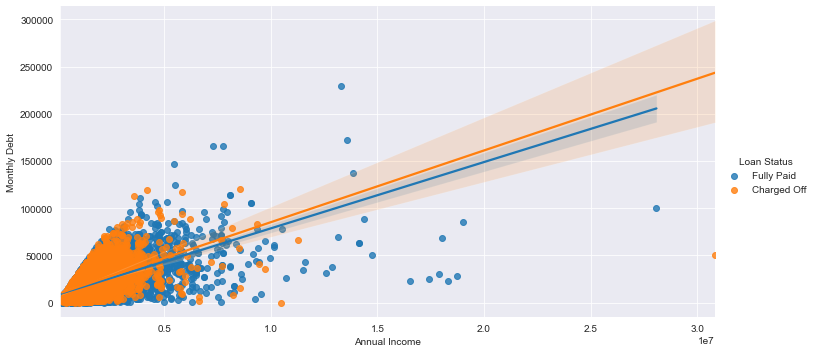

In [33]:
sns.lmplot(x = 'Annual Income' , y = 'Monthly Debt', 
           hue = 'Loan Status', data = credit_data, aspect = 2)

We have added 'Term' as Hue.We have customised hue palette('Set1'). Markers can be fixed for each level of 'hue' by using markers argument.
The increase in value of  'Monthly Debt' with an unit increase in the value of  'Annual income' will be more for 'Short term' customers than the 'Long term' customers. Few outliers are observed which are in 'Short Term' for the 'Term' variable. One outlier is observed for 'long term' category in the right extreme.


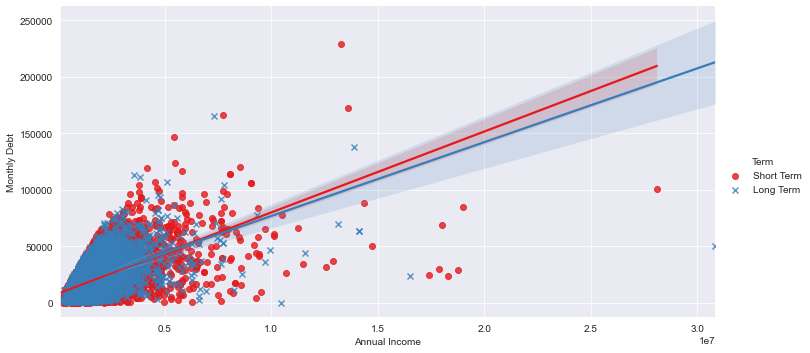

In [34]:
sns.lmplot(x = 'Annual Income' , y = 'Monthly Debt', 
           hue = 'Term', markers = ['o', 'x'], palette = 'Set1' , 
           data = credit_data, aspect = 2);

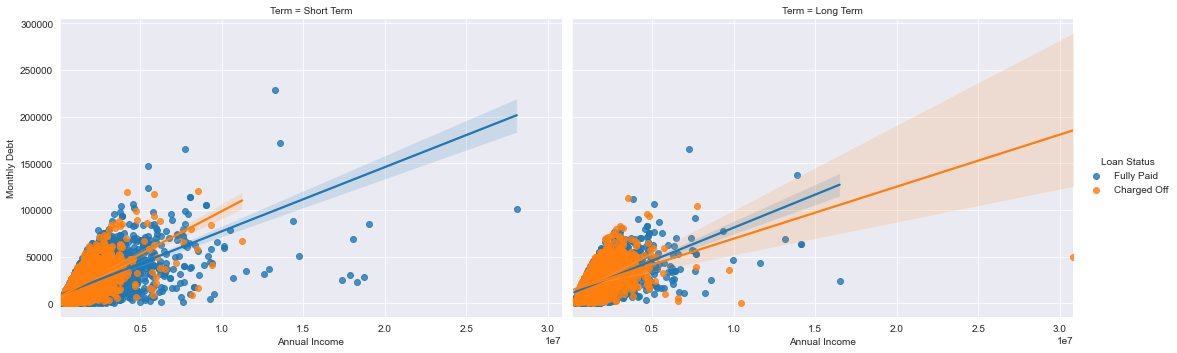

In [36]:
sns.lmplot(x ='Annual Income' , y = 'Monthly Debt', hue = 'Loan Status', 
           col = 'Term', data = credit_data , aspect = 1.5)

Here we have added another variable 'Years in current job' through 'row' argument.The levels of variable 'Years in current job' are shown in different rows. It can be used cautiously to observe the relationships under different scenarios in every facets.

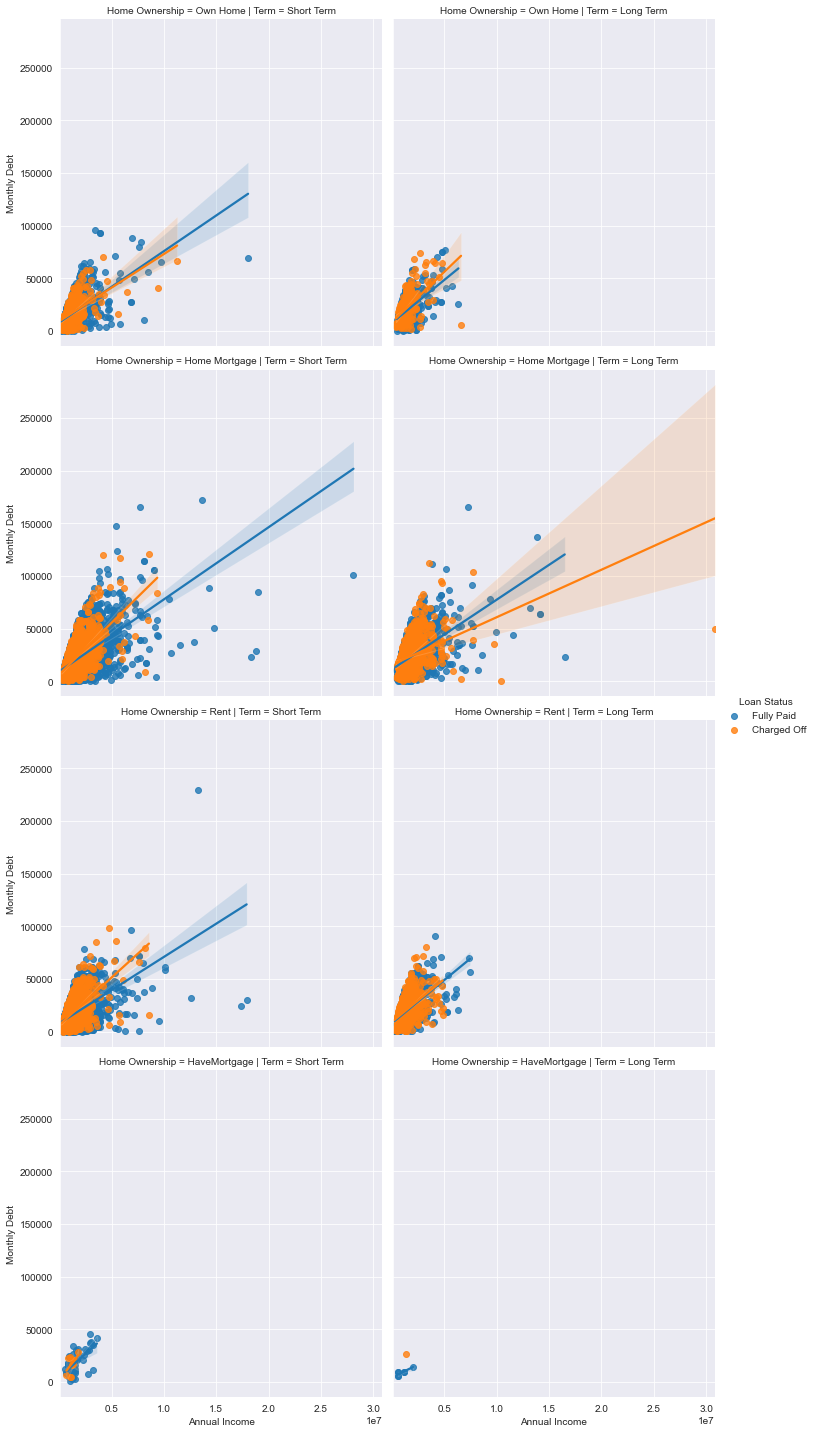

In [37]:
sns.lmplot(x ='Annual Income' , y = 'Monthly Debt',
           hue = 'Loan Status', col = 'Term', 
           row = 'Home Ownership', data = credit_data);

For building a classification model for 'Loan Status', We have converted the levels of 'Loan Status' to Boolean( 0 for 'Charged Off' and 1 for 'Fully paid')

In [38]:
mapping = {'Fully Paid' : 1, 'Charged Off' : 0}

credit_data['Loan Status'] = credit_data['Loan Status'].replace(mapping)

credit_data.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,1,99999999,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18,1,297996,750090.0,0.0,0.0
6,273581de-85d8-4332-81a5-19b04ce68666,90a75dde-34d5-419c-90dc-1e58b04b3e35,1,217646,Short Term,730.0,1184194.0,< 1 year,Home Mortgage,Debt Consolidation,10855.08,19.6,10.0,13,1,122170,272052.0,1.0,0.0
8,8af915d9-9e91-44a0-b5a2-564a45c12089,af534dea-d27e-4fd6-9de8-efaa52a78ec0,1,548746,Short Term,678.0,2559110.0,2 years,Rent,Debt Consolidation,18660.28,22.6,33.0,4,0,437171,555038.0,0.0,0.0
10,32c2e48f-1ba8-45e0-a530-9a6622c18d9c,0de7bcdb-ebf4-4608-ba39-05f083f855b6,1,99999999,Short Term,728.0,714628.0,3 years,Rent,Debt Consolidation,11851.06,16.0,76.0,16,0,203965,289784.0,0.0,0.0
12,403d7235-0284-4bb6-919a-09402fecbf7b,11581f68-de3c-49d8-80d9-22268ebb323b,1,99999999,Short Term,740.0,776188.0,< 1 year,Own Home,Debt Consolidation,11578.22,8.5,25.0,6,0,134083,220220.0,0.0,0.0


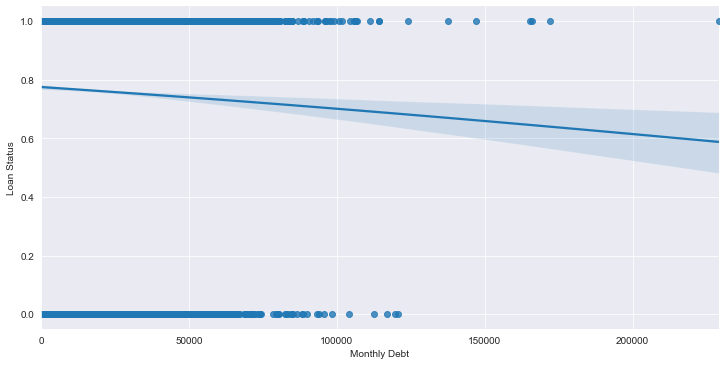

In [40]:
sns.lmplot(x = 'Monthly Debt', y = 'Loan Status', 
           data = credit_data, aspect = 2, logistic = True)

Here We have fitted a logistic regression model, such that the regression line shows the estimated probability of y = 1 i.e 'Fully Paid' Loan Status for a given value of x i.e Credit Score.
It can be observed that as we move towards  higher values of 'Credit ' , the probabilty of paying the Loan Fully is becoming 0 i.e probabilty of fully repaying the  loan  is becoming  minimum.
This is a computationally expensive process so the 'ci' argument can be turned off(ci=None).

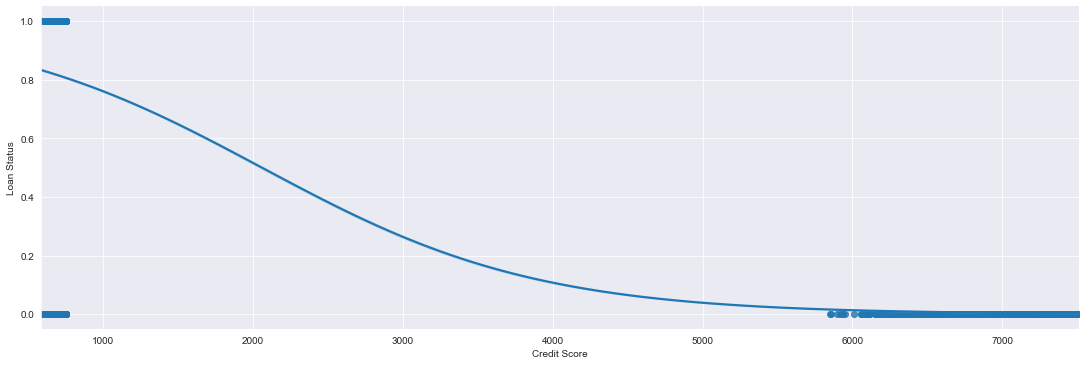

In [41]:
sns.lmplot(x = 'Credit Score', y = 'Loan Status', 
           data = credit_data, aspect = 2, logistic = True)

Here, We have drawn a scatter plot of 'Monthly Debt' and 'Current Credit Balance'.Positive correlation is observed and quite a few outliers are visible towards the upper extreme of Current Credit balance.

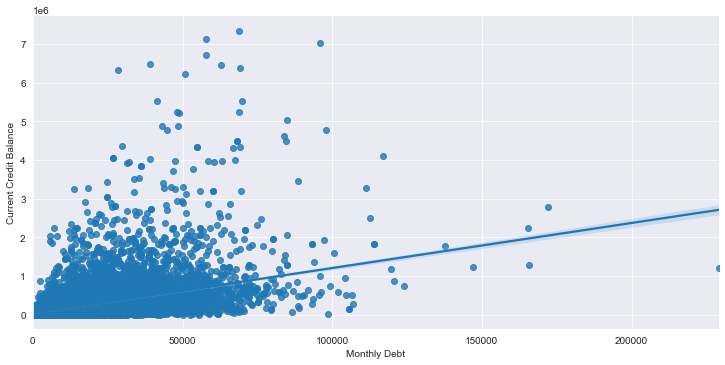

In [42]:
sns.lmplot(x = 'Monthly Debt', y = 'Current Credit Balance', 
           data = credit_data, aspect = 2)

Now, We have applied robust Regression using 'robust' argument.In this case,the outliers are given lower weights.
It can be observed that the slope of  Regression line has decreased as the outliers towards the upper extreme of Current Credit Balance have been deweighed. This is also a computationally expensive process so the 'ci' argument can be turned off(ci=None)

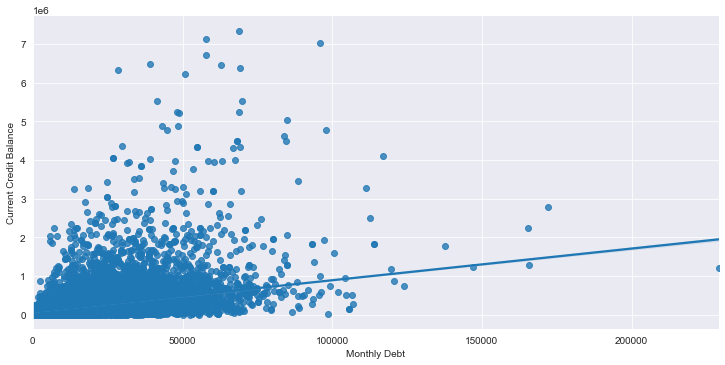

In [43]:
sns.lmplot(x = 'Monthly Debt', y = 'Current Credit Balance', 
           data = credit_data, aspect = 2, robust = True)